In [17]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from q_function_nn import QFunctionNN
import torch
from train_dql import train_dql

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Env 

In [6]:
# Init a built-in cartpole environment
env = gym.make("CartPole-v1", render_mode="rgb_array")

In [7]:
env

<TimeLimit<OrderEnforcing<PassiveEnvChecker<CartPoleEnv<CartPole-v1>>>>>

In [8]:
env.action_space

Discrete(2)

In [9]:
# There are only two actions for the cartpole
action_map = {0: 'push left', 1: 'push right'}

In [10]:
obs, info = env.reset()

In [11]:
obs

array([ 0.01320945, -0.00656318, -0.0442783 ,  0.02487881], dtype=float32)

In [8]:
frame = env.render()

/home/eric/.cache/pypoetry/virtualenvs/rl-fundamental-iovhCHDa-py3.10/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1342:(snd_func_refer) error evaluating name
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5727:(snd_config_expand) Evaluate er

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

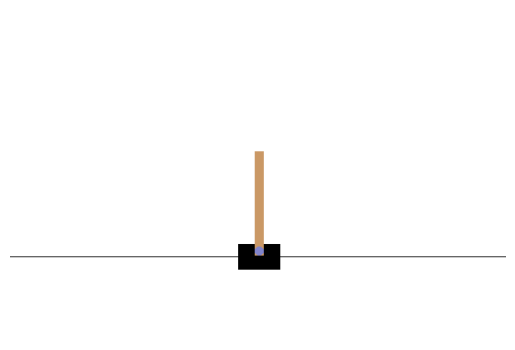

In [9]:
plt.imshow(frame)
plt.axis('off')

In [12]:
# make an action 0
action = 0
obs, reward, terminated, truncated, info = env.step(action)

In [58]:
terminated, truncated

(True, False)

In [59]:
obs

array([-0.11101025, -1.1317341 ,  0.22578126,  1.98677   ], dtype=float32)

In [60]:
reward

1.0

In [61]:
info

{}

In [62]:
def q_function(state):
    return np.random.rand(2)

# Train Loop

Deep Q-learning.

Basic Q-learning:

$$Q_{new}(s, a) = Q_{old}(s, a) + \eta[R + \gamma \max \{Q(s^{\prime})\} - Q_{old}(s, a)]$$

In [21]:
# Config
num_episodes = 1000
max_steps_per_episode = 200
epsilon = 1
input_dim = 4
hidden_dim = 128
output_dim = 2

In [22]:
# Init policy NN and target NN
policy_nn = QFunctionNN(state_dim=input_dim, action_dim=output_dim, hidden_dim=hidden_dim)
# copy weights from policy NN to target NN
target_nn = QFunctionNN(state_dim=input_dim, action_dim=output_dim, hidden_dim=hidden_dim)
target_nn.load_state_dict(policy_nn.state_dict())

<All keys matched successfully>

In [23]:
# Create a loss function and an optimizer
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(policy_nn.parameters(), lr=1e-3)

In [ ]:
train_dql()